# 토스 코호트 시간 분리·임시 라벨 감사 (G3 중간점)

**한 줄 답:** 첫 10분 행동과 이후 24시간 행동은 누수 없이 분리됐지만, 분석 가능 표본이 46대이고 임시 양성이 8대뿐이라 모델 학습 표본으로 확정하지 않았다.

**사전 통과 기준:** 집단이 겹치지 않고 전체 표본을 모두 포함하며, 피처/라벨 경계 위반이 0이어야 한다. 라벨의 업무적 의미와 표본 적정성은 별도로 판단한다.

**실행 SQL:** [`../sql/g3_toss_early_later_label_audit.sql`](../sql/g3_toss_early_later_label_audit.sql). `platform='toss'`, 비베타 표시 기기, 완전한 24시간 관측 가능 기기만 포함했다. 첫 이벤트 후 `[0,10분)`을 피처 구간, `[10분,24시간)`을 임시 라벨 구간으로 고정했다. 자동·로그인·장부 이벤트는 제외했다. 기기 ID는 쿼리 밖으로 내보내지 않았다.


In [1]:
from pathlib import Path
import sys, pandas as pd
from IPython.display import display
root = Path.cwd().parents[1] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(root / 'ml'))
from calm_ml import report as R
R.setup()
out = root / 'ml/reports/g3_toss_early_later_2026-09-15'
d = pd.read_csv(out / 'label_audit.csv')
n = int(d.devices.sum())
assert n == 46
assert int(d.feature_boundary_violations.sum()) == 0
assert int(d.label_boundary_violations.sum()) == 0
d['후속 행동률'] = d.later_active_devices / d.devices
display(d)
print(f'전체: {n}대, 임시 양성 {d.later_active_devices.sum()}대 ({d.later_active_devices.sum()/n:.1%})')


,early_segment,devices,later_active_devices,later_inactive_devices,early_action_events,later_action_events,feature_boundary_violations,label_boundary_violations,후속 행동률
0,0회,22,2,20,0,15,0,0,0.090909
1,1~5회,7,0,7,20,0,0,0,0.000000
2,6회 이상,17,6,11,859,2431,0,0,0.352941


전체: 46대, 임시 양성 8대 (17.4%)


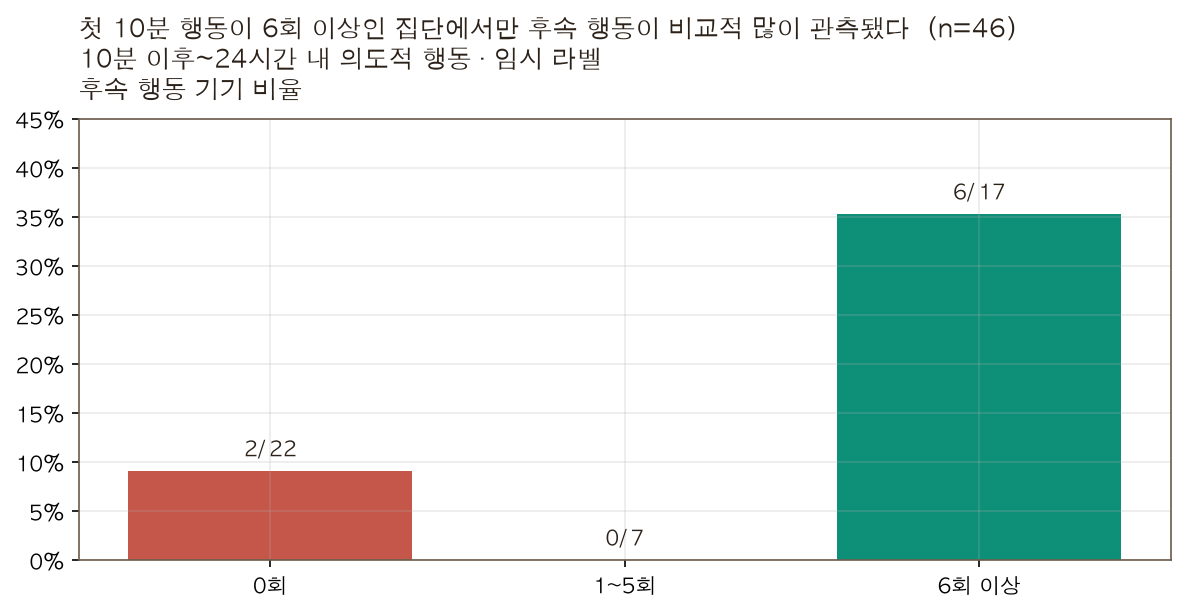

In [2]:
fig, ax = R.new('첫 10분 행동이 6회 이상인 집단에서만 후속 행동이 비교적 많이 관측됐다', n, sub='10분 이후~24시간 내 의도적 행동 · 임시 라벨', ylab='후속 행동 기기 비율')
bars = ax.bar(d.early_segment, d['후속 행동률'], color=R.PALETTE[:3])
for bar, yes, total in zip(bars, d.later_active_devices, d.devices):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.015, f'{yes}/{total}', ha='center')
ax.set_ylim(0, 0.45)
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
fig.tight_layout()
chart = out / 'later_action_rate_by_early_segment.png'
fig.savefig(chart, dpi=150)
display(R.show(chart))


## 결과

- 24시간을 완전히 관측할 수 있는 기기는 46대다. 9월 12일 후반 신규 기기 3대는 관측 종료 편향을 피하려 제외됐다.
- 첫 10분 0회: 22대 중 후속 행동 2대(9.1%). 1~5회: 7대 중 0대(0%). 6회 이상: 17대 중 6대(35.3%). 전체 임시 양성은 8대(17.4%)다.
- 피처 경계 위반과 라벨 경계 위반은 모두 0이다. 시간 분리 자체는 통과했다.

## 이 숫자로 말할 수 없는 것

표본과 양성이 작아 1~5회 집단의 0%를 안정적인 패턴으로 볼 수 없다. `platform` 태그 전 이탈과 미표시 베타 테스터 문제도 남는다. 임시 라벨은 재방문·장기 잔존·특정 지역 도달과 같지 않으며, 사용자와 예측 목표를 합의하지 않았으므로 모델 목표로 확정할 수 없다. 집계 결과만 저장해 기기별 재현성·중복·개별 피처 누수 검사도 아직 끝나지 않았다.

## 판정과 다음 확인

**G3 중간 결과: 시간 경계는 통과, 표본·라벨 확정은 보류.** 다음 세션에서 예측하려는 실제 행동 하나를 합의한 뒤 기기별 익명 학습표를 재현 가능하게 만들고 양성 수·시간 누수를 다시 검사한다. 이번 세션은 여기서 멈춘다.
